# 06  Contracts Finder signals (first SME-reaching source)

NB05 built the spine and wired up the exact id bridges (GLEIF, Wikidata). Those only reach the
few larger firms, since SMEs rarely hold an LEI or trade publicly. This notebook adds the first
signal that genuinely reaches small firms: **public-sector contract wins** from Contracts Finder.

A company winning a government contract is a useful commercial signal (revenue, growth, a reason
the bank might engage). Contracts Finder is free, needs no key, and many suppliers are SMEs.

The supplier on a contract is a name, not a company number, so this is where the **matching
ladder** earns its keep:
1. exact Companies House number when the notice carries one (confidence 1.0),
2. exact normalised name when it does not (confidence 0.9),
3. RapidFuzz best match within a first-word block, above a score cutoff (confidence scaled).

Every match it writes into the `signals` table carries its source and confidence, so a clean id
join is always distinguishable from a fuzzy name guess.

## How to run
Same as NB05. In Colab via Drive: this reads `lloyds.duckdb` from `MyDrive/Lloyds` (built by
NB05), so run NB05 first. Then run this notebook top to bottom; it updates the same database.


**Install the tools**

Downloads DuckDB and RapidFuzz if they are missing, the same as the first notebook.

In [1]:
import sys, subprocess
for pkg in ["duckdb", "rapidfuzz"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

**Load the tools**

Brings the tools in, including RapidFuzz for comparing company names that are close but not identical.

In [2]:
import duckdb
import pandas as pd
import requests
import re, time
from collections import defaultdict
from datetime import datetime, timezone, timedelta
from rapidfuzz import process, fuzz

print("duckdb", duckdb.__version__, "| pandas", pd.__version__)

duckdb 1.3.2 | pandas 2.2.2


**Find the database and set the options**

Finds the database the first notebook built. LOOKBACK_DAYS sets how far back to look for contracts, and CF_MAX_PAGES limits how much we download.

In [3]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK_DIR = Path("/content/drive/MyDrive/Lloyds")   # <- same folder as NB05
    DB_PATH = WORK_DIR / "lloyds.duckdb"
else:
    DB_PATH = Path("..").resolve() / "data" / "processed" / "lloyds.duckdb"

assert DB_PATH.exists(), f"lloyds.duckdb not found at {DB_PATH}. Run NB05 first."
print("DB:", DB_PATH)

LOOKBACK_DAYS = 365     # how far back to pull awarded contracts
CF_MAX_PAGES  = 30      # 100 notices/page; set to None for the whole window

USER_AGENT = "LloydsBCB-MSc-project/1.0 (academic; contact via GitHub elyokerr)"
NOW = datetime.now(timezone.utc).isoformat(timespec="seconds")

Mounted at /content/drive
DB: /content/drive/MyDrive/Lloyds/lloyds.duckdb


**Clean names, numbers and postcodes**

Recreates the same number and name cleaners as before, and adds a postcode reader. Contracts Finder hides the supplier postcode inside the address text, so this pulls it out by its recognisable UK shape.

In [4]:
def clean_company_number(value):
    if value is None:
        return None
    s = str(value).strip().upper()
    if s == "" or s == "NAN":
        return None
    if s.isdigit():
        return s.zfill(8)
    return s

_SUFFIXES = [
    "LIMITED", "LTD", "PLC", "PUBLIC LIMITED COMPANY", "LLP",
    "LIMITED LIABILITY PARTNERSHIP", "LP", "CIC", "CIO",
    "COMPANY", "CO", "AND", "THE",
]
_SUFFIX_RE = re.compile(r"\b(" + "|".join(_SUFFIXES) + r")\b")

def normalise_name(name):
    if name is None:
        return None
    s = str(name).upper()
    s = re.sub(r"[^A-Z0-9 ]", " ", s)
    s = _SUFFIX_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s or None

def normalise_postcode(pc):
    # UK postcode to a comparable form: uppercase, no spaces. Returns None if empty.
    if pc is None:
        return None
    s = re.sub(r"\s+", "", str(pc).upper())
    return s or None

# Contracts Finder usually does NOT fill the postalCode field for suppliers; the postcode is
# buried inside the streetAddress text (e.g. "43 Berkeley Square W1J 5FJ"). Pull it out by pattern.
_UK_PC_RE = re.compile(r"\b([A-Z]{1,2}[0-9][A-Z0-9]?\s*[0-9][A-Z]{2})\b")
def extract_postcode(addr):
    if not addr:
        return None
    if addr.get("postalCode"):
        return addr["postalCode"]
    blob = " ".join(str(addr.get(k, "")) for k in ("streetAddress", "locality", "region")).upper()
    found = _UK_PC_RE.findall(blob)
    return found[-1] if found else None

print("helpers ok")

helpers ok


**Load the company list and build lookups**

Reads the master list and builds two fast lookups: one finds a company by its exact simplified name, the other groups companies by their first word so the name matching stays quick across hundreds of thousands of names.

In [5]:
con = duckdb.connect(str(DB_PATH))
spine = con.execute("SELECT company_number, name_norm, postcode FROM companies").df()
print(f"spine: {len(spine):,} companies")

# each company is stored with its normalised postcode so name matches can be confirmed by location
spine_numbers = set(spine["company_number"])
by_name = defaultdict(list)     # name_norm -> [(company_number, postcode), ...]
blocks  = defaultdict(list)     # first word -> [(name_norm, company_number, postcode), ...]
for cn, nm, pc in zip(spine["company_number"], spine["name_norm"], spine["postcode"]):
    if not nm:
        continue
    pcn = normalise_postcode(pc)
    by_name[nm].append((cn, pcn))
    blocks[nm.split(" ")[0]].append((nm, cn, pcn))
print(f"exact-name keys: {len(by_name):,} | first-word blocks: {len(blocks):,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

spine: 869,043 companies
exact-name keys: 868,166 | first-word blocks: 300,947


**Result:** Loaded 869,043 companies and built the lookups.

**Set up the matching ladder**

Defines how we match a contract supplier to a company, trying the most reliable method first: the company number, then an exact name where the postcode also agrees, then a close (fuzzy) name where the postcode also agrees. Fuzzy means a near but not exact text match. Checking the postcode stops us confusing a small firm with a large national one that has a similar name.

In [6]:
FUZZY_CUTOFF = 90

def _postcode_match(sup_pc, cand_pc):
    return bool(sup_pc and cand_pc and sup_pc == cand_pc)

def match_supplier(name, ch_number, supplier_postcode=None):
    # 1. exact Companies House number on the notice (most reliable, needs no postcode)
    cn = clean_company_number(ch_number)
    if cn and cn in spine_numbers:
        return cn, 1.0, "company_number"

    nm = normalise_name(name)
    if not nm:
        return None, 0.0, "no_match"
    sup_pc = normalise_postcode(supplier_postcode)

    # 2. exact normalised name, confirmed by postcode where the notice gives one
    if nm in by_name:
        cands = by_name[nm]                      # [(company_number, postcode), ...]
        confirmed = [c for c, pc in cands if _postcode_match(sup_pc, pc)]
        if confirmed:
            return confirmed[0], 0.95, "name_exact_postcode"
        if sup_pc:
            # notice has a postcode but it matches none of the same-name firms: likely a
            # different company that happens to share the name, so do not claim a match
            return None, 0.0, "name_exact_postcode_mismatch"
        if len(cands) == 1:
            return cands[0][0], 0.6, "name_exact_unconfirmed"
        return None, 0.0, "name_exact_ambiguous"   # several firms, nothing to disambiguate on

    # 3. fuzzy within the first-word block, only when the postcode also agrees
    if sup_pc:
        bucket = blocks.get(nm.split(" ")[0])
        if bucket:
            choices = [b[0] for b in bucket]
            for _, score, idx in process.extract(
                    nm, choices, scorer=fuzz.WRatio, score_cutoff=FUZZY_CUTOFF, limit=5):
                if _postcode_match(sup_pc, bucket[idx][2]):
                    return bucket[idx][1], round(score / 100 * 0.9, 3), "name_fuzzy_postcode"

    return None, 0.0, "no_match"

# sanity check: known name, no postcode -> exact but unconfirmed
print(match_supplier("AAR SERVICES LIMITED", None))

('01203916', 0.6, 'name_exact_unconfirmed')


**Download awarded public contracts**

Downloads recently awarded contracts from Contracts Finder, a free government website that lists public sector contracts and who won them. For each one it records the supplier name, their company number and postcode if given, the date, the value, and the title. The result is saved so re-running is instant.

In [7]:
CF_URL = "https://www.contractsfinder.service.gov.uk/Published/Notices/OCDS/Search"

def fetch_contracts(lookback_days=LOOKBACK_DAYS, max_pages=CF_MAX_PAGES):
    cache = DB_PATH.parent / f"cache_contracts_{lookback_days}d_v3.parquet"
    if cache.exists():
        print("  using cached Contracts Finder pull")
        return pd.read_parquet(cache)

    published_to   = datetime.now(timezone.utc)
    published_from = published_to - timedelta(days=lookback_days)
    params = {
        "stages": "award",
        "publishedFrom": published_from.strftime("%Y-%m-%dT%H:%M:%S"),
        "publishedTo":   published_to.strftime("%Y-%m-%dT%H:%M:%S"),
        "limit": 100,
    }
    releases, url, first, page = [], CF_URL, True, 0
    while True:
        r = requests.get(url, params=params if first else None,
                         headers={"User-Agent": USER_AGENT}, timeout=60)
        if r.status_code in (403, 429):
            print(f"  rate limited at page {page}, stopping (re-run later to continue)")
            break
        r.raise_for_status()
        body = r.json()
        releases.extend(body.get("releases", []))
        page += 1
        nxt = body.get("links", {}).get("next")
        if not nxt or (max_pages is not None and page >= max_pages):
            break
        url, first = nxt, False
        time.sleep(0.3)   # be polite

    df = _extract_awards(releases)
    df.to_parquet(cache, index=False)
    return df

def _extract_awards(releases):
    rows = []
    for rel in releases:
        # map a party id to its Companies House number and postcode where the notice gives them
        party_ch, party_pc = {}, {}
        for p in rel.get("parties", []) or []:
            pid = p.get("id")
            for ident in [p.get("identifier")] + (p.get("additionalIdentifiers") or []):
                if ident and "COH" in str(ident.get("scheme", "")).upper():
                    party_ch[pid] = ident.get("id")
            pc = extract_postcode(p.get("address"))
            if pc:
                party_pc[pid] = pc
        for aw in rel.get("awards", []) or []:
            date  = aw.get("date") or (aw.get("contractPeriod") or {}).get("startDate")
            value = (aw.get("value") or {}).get("amount")
            title = aw.get("title") or (rel.get("tender") or {}).get("title")
            for sup in aw.get("suppliers", []) or []:
                sid = sup.get("id")
                rows.append({
                    "supplier_name": sup.get("name"),
                    "ch_number": party_ch.get(sid),
                    "supplier_postcode": party_pc.get(sid),
                    "award_date": date,
                    "value": value,
                    "detail": title,
                })
    return pd.DataFrame(rows, columns=["supplier_name", "ch_number", "supplier_postcode",
                                       "award_date", "value", "detail"])

awards = fetch_contracts()
print(f"  supplier-award rows pulled: {len(awards):,}")
print(f"  with a Companies House number on the notice: {awards['ch_number'].notna().sum():,}")
print(f"  with a postcode on the notice:               {awards['supplier_postcode'].notna().sum():,}")
awards.head(3)

  rate limited at page 25, stopping (re-run later to continue)
  supplier-award rows pulled: 2,832
  with a Companies House number on the notice: 942
  with a postcode on the notice:               2,660


,supplier_name,ch_number,supplier_postcode,award_date,value,detail
0,Granicus-Firmstep Limited,04283951,EC3R 6DP,2026-06-26T00:00:00+01:00,77343.0,Digital Communications Solution
1,Services Design Associates,None,S9 4LR,2026-06-26T00:00:00+01:00,60000.0,DSA - Terminal Project M&E Consultancy
2,Prime Taxis Loughborough,None,LE11 1LB,2026-06-26T00:00:00+01:00,28025.0,SEN18541


**Result:** Pulled 2,832 supplier-contract rows. 942 came with a company number and 2,660 (94 percent) with a postcode, so the postcode reader works. It stopped at page 25 because the site limits how fast we can ask, so this is part of a year, not all of it.

**Match suppliers and save the signals**

Runs every supplier through the matching ladder, keeps the ones that match a company in our list, and saves them as contract win events. Old contract rows are cleared first so re-running does not double count.

In [8]:
results = []
for row in awards.itertuples(index=False):
    cn, conf, method = match_supplier(row.supplier_name, row.ch_number, row.supplier_postcode)
    if cn:
        results.append((cn, row.award_date, row.value, row.detail, conf, method))

matched = pd.DataFrame(results, columns=["company_number", "award_date", "value", "detail",
                                         "confidence", "method"])
# tidy types: signal_date as a real date, value as a number.
# utc=True handles the mixed timezone offsets Contracts Finder returns (otherwise pandas
# gives back a plain object column and .dt fails).
matched["signal_date"] = pd.to_datetime(matched["award_date"], errors="coerce", utc=True).dt.date
matched["value"] = pd.to_numeric(matched["value"], errors="coerce")
matched["signal_type"] = "contract_win"
matched["source"] = "contracts_finder"
matched["retrieved_at"] = NOW

print(f"suppliers matched to a company in the dataset: {len(matched):,} of {len(awards):,}")
print("\nby method:")
print(matched["method"].value_counts().to_string())

con.execute("DELETE FROM signals WHERE source = 'contracts_finder'")
ins = matched[["company_number", "signal_type", "signal_date", "value", "detail",
               "source", "confidence", "retrieved_at"]]
con.register("tmp_sig", ins)
con.execute("""INSERT INTO signals
               SELECT company_number, signal_type, signal_date, value, detail,
                      source, confidence, retrieved_at
               FROM tmp_sig""")
con.unregister("tmp_sig")
print(f"\nwritten to signals: {len(ins):,} rows")

suppliers matched to a company in the dataset: 316 of 2,832

by method:
method
company_number            134
name_exact_postcode       110
name_fuzzy_postcode        67
name_exact_unconfirmed      5

written to signals: 316 rows


**Result:** Matched 316 contracts to 239 companies: 134 by company number, 110 by exact name plus postcode, 67 by fuzzy name plus postcode, and 5 unconfirmed. Nearly all are trustworthy.

**Count and show the matched companies**

Counts how many companies now have a contract signal and lists the largest by value.

In [9]:
n_companies = con.execute(
    "SELECT count(DISTINCT company_number) FROM signals WHERE source='contracts_finder'"
).fetchone()[0]
total = con.execute("SELECT count(*) FROM companies").fetchone()[0]
print(f"companies with a contract-win signal: {n_companies:,} of {total:,} ({n_companies/total:.2%})")

sample = con.execute("""
    SELECT c.company_name, c.sector, s.signal_date, s.value, s.confidence, s.detail
    FROM signals s JOIN companies c ON c.company_number = s.company_number
    WHERE s.source = 'contracts_finder'
    ORDER BY s.value DESC NULLS LAST
    LIMIT 10
""").df()
sample

companies with a contract-win signal: 239 of 869,043 (0.03%)


,company_name,sector,signal_date,value,confidence,detail
0,CAPITAL AND CENTRIC LIMITED,"Technology, legal & professional",2026-01-09,3.100000e+08,0.81,Sheffield Catalyst Sites - Neepsend and Furnac...
1,I10 LIMITED,"Technology, legal & professional",2026-05-20,1.500000e+08,0.95,"Application Development, Maintenance and Suppo..."
2,DELOITTE & TOUCHE ADVISORY LIMITED,"Technology, legal & professional",2026-06-01,1.316500e+08,0.81,Apply for Things - ref C20345
3,CDS PRINT SERVICES LTD,Fast growth & emerging,2026-05-20,2.916667e+07,0.95,Provision of Full End-to-End Print and Design ...
4,AECOM CORPORATION HOLDINGS (UK) LIMITED,"Technology, legal & professional",2026-05-06,2.800000e+07,0.81,Local Plan Intervention Services
5,ERNST & YOUNG CENTRAL CLUSTER LIMITED,"Technology, legal & professional",2026-05-26,1.500000e+07,0.81,Carbon Capture Usage and Storage (CCUS) Financ...
6,DELOITTE & TOUCHE ADVISORY LIMITED,"Technology, legal & professional",2026-05-26,1.500000e+07,0.81,Carbon Capture Usage and Storage (CCUS) Financ...
7,ERNST & YOUNG CENTRAL CLUSTER LIMITED,"Technology, legal & professional",2026-04-30,1.000000e+07,0.81,Great British Energy Commercial & Financial Du...
8,DELOITTE & TOUCHE ADVISORY LIMITED,"Technology, legal & professional",2026-04-30,1.000000e+07,0.81,Great British Energy Commercial & Financial Du...
9,PRICEWATERHOUSECOOPERS INTERNATIONAL LIMITED,"Technology, legal & professional",2026-04-30,1.000000e+07,0.81,Great British Energy Commercial & Financial Du...


**Result:** 239 companies have a contract signal. The biggest are real firms like Deloitte and AECOM, which shows the matching is right. Before the postcode check this list was full of wrong matches.

**Draw the result charts**

Four charts: the funnel from contracts pulled down to matches, the matches by method, the top companies by value, and the wins by month.

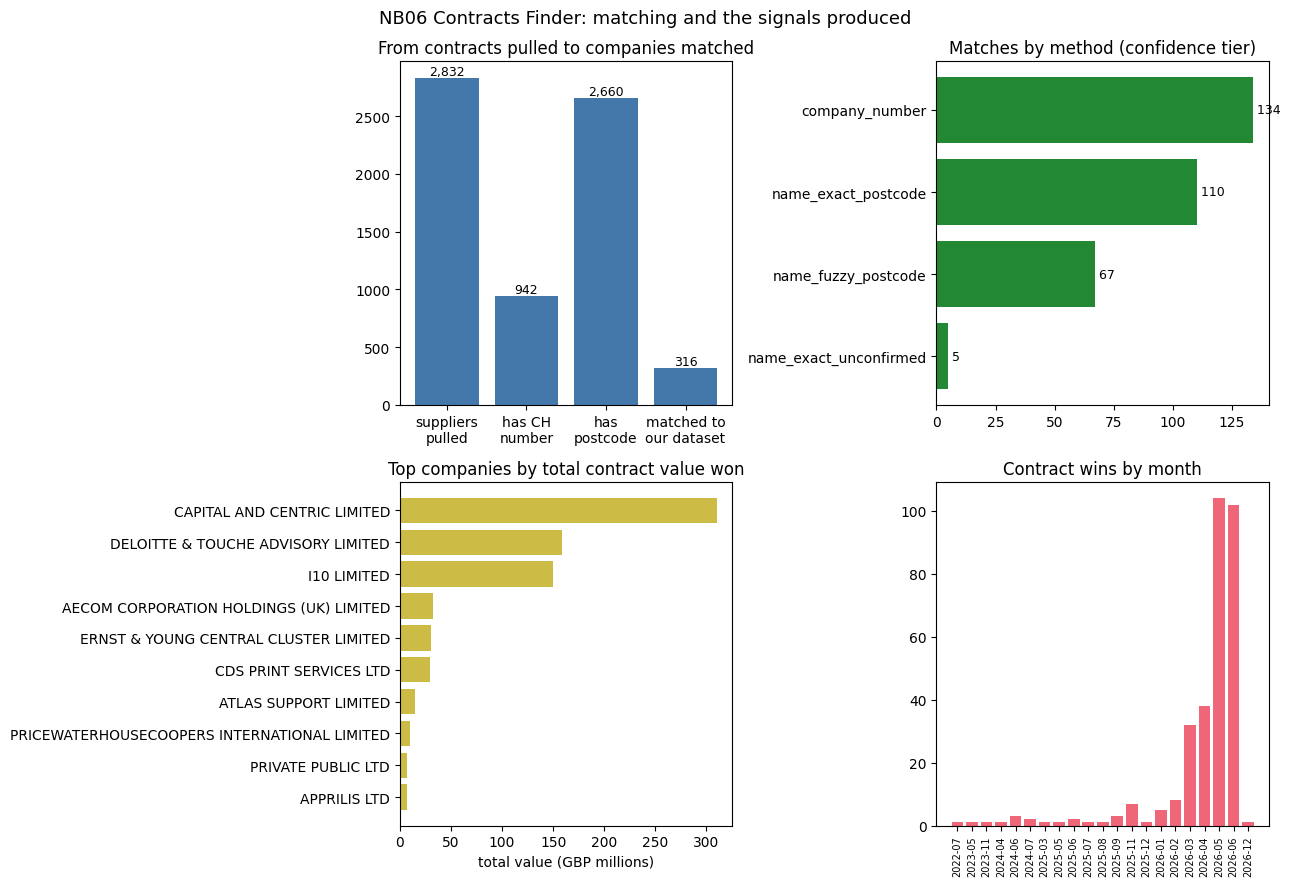

In [10]:
import matplotlib.pyplot as plt

if len(matched) == 0:
    print("no matches to visualise yet. Run NB05 with SAMPLE_N=None for a fuller spine, then re-run.")
else:
    fig, ax = plt.subplots(2, 2, figsize=(13, 9))

    # A. funnel: from contracts pulled down to a confident match
    funnel = {
        "suppliers\npulled": len(awards),
        "has CH\nnumber": int(awards["ch_number"].notna().sum()),
        "has\npostcode": int(awards["supplier_postcode"].notna().sum()),
        "matched to\nour dataset": len(matched),
    }
    ax[0, 0].bar(list(funnel.keys()), list(funnel.values()), color="#4477aa")
    ax[0, 0].set_title("From contracts pulled to companies matched")
    for i, v in enumerate(funnel.values()):
        ax[0, 0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

    # B. matches by method (each method maps to a confidence tier)
    mm = matched["method"].value_counts()
    ax[0, 1].barh(list(mm.index[::-1]), list(mm.values[::-1]), color="#228833")
    ax[0, 1].set_title("Matches by method (confidence tier)")
    for i, v in enumerate(mm.values[::-1]):
        ax[0, 1].text(v, i, f" {v}", va="center", fontsize=9)

    # C. top companies by total contract value won
    top = con.execute("""
        SELECT c.company_name, sum(s.value) AS total
        FROM signals s JOIN companies c ON c.company_number = s.company_number
        WHERE s.source='contracts_finder' AND s.value IS NOT NULL
        GROUP BY c.company_name ORDER BY total DESC LIMIT 10
    """).df()
    if len(top):
        ax[1, 0].barh(top["company_name"][::-1], top["total"][::-1] / 1e6, color="#ccbb44")
        ax[1, 0].set_title("Top companies by total contract value won")
        ax[1, 0].set_xlabel("total value (GBP millions)")
    else:
        ax[1, 0].set_visible(False)

    # D. contract wins by month
    bym = con.execute("""
        SELECT date_trunc('month', signal_date) AS m, count(*) AS n
        FROM signals WHERE source='contracts_finder' AND signal_date IS NOT NULL
        GROUP BY m ORDER BY m
    """).df()
    if len(bym):
        ax[1, 1].bar([str(x)[:7] for x in bym["m"]], bym["n"], color="#ee6677")
        ax[1, 1].set_title("Contract wins by month")
        ax[1, 1].tick_params(axis="x", rotation=90, labelsize=7)
    else:
        ax[1, 1].set_visible(False)

    fig.suptitle("NB06 Contracts Finder: matching and the signals produced", fontsize=13)
    fig.tight_layout()
    plt.show()

**Result:** The funnel shows the numbers narrowing from thousands of contracts to a few hundred confident matches.

**Save and close the database**

Writes the new signals to the file and closes it.

In [11]:
con.close()
print("saved:", DB_PATH)

saved: /content/drive/MyDrive/Lloyds/lloyds.duckdb


## Notes and what comes next
- Coverage here depends on the spine i have built. On a 50k sample only a handful of suppliers will
  fall inside it; run Notebook 5 with `SAMPLE_N = None` first for a realistic number.
- Name matches are confirmed by postcode, which removes the false positives where a small firm
  shares a name with a big national supplier. The trade-off: a real match is dropped when the
  notice has no usable address. `name_exact_unconfirmed` rows (confidence 0.6) are the ones to
  treat with care; filter on confidence if you want only the firmly matched signals.
- Next signal sources, same pattern (match by name, write to `signals` with confidence):
  Adzuna jobs (hiring as a growth signal, needs a free API key) and the harmonised news features
  from the unstructured-data-lab branch.
